In [1]:
# Credit Card Fraud · сильный дисбаланс (~0.17% fraud)

#**Контекст:** 284 807 транзакций, из них 492 — мошеннические. Дисбаланс ~1:578.

#**Целевые метрики:** PR-AUC, MCC, Balanced Accuracy.

#**Почему:** accuracy = 99.8% даже у модели, которая **вообще ничего не ловит**.
#ROC-AUC тоже обманывает — на сильном дисбалансе она оптимистична.
#Честные метрики здесь: PR-AUC (precision-recall area) и MCC (matthews correlation coefficient),
#которые дают высокий балл только при реально хорошем разделении всех четырёх клеток confusion matrix.

#**Главный вывод ноутбука:** одна цифра «0.999 accuracy» ничего не значит.
#Нужно смотреть минимум 5 метрик, чтобы понять, работает ли модель.

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'credit_fraud'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/credit_fraud
ART_DIR  : /app/artifacts/classification/credit_fraud


In [3]:
def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """Собирает метрики классификации в один словарь."""
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
    }
    if len(np.unique(y_true)) == 2 and y_proba is not None:
        p = y_proba[:, positive_label] if y_proba.ndim == 2 else y_proba
        m['roc_auc'] = roc_auc_score(y_true, p)
        m['pr_auc']  = average_precision_score(y_true, p)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        m['specificity'] = tn / (tn + fp) if (tn + fp) else 0.0
        m['sensitivity'] = tp / (tp + fn) if (tp + fn) else 0.0
    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None):
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

#Датасет `mlg-ulb/creditcardfraud` с Kaggle. 284 807 транзакций, 30 числовых признаков
#(V1–V28 — результат PCA, плюс Time и Amount), целевая `Class`: 0 = normal, 1 = fraud.

#Скачиваем через `kagglehub` — уже есть в `requirements.txt`. Если Kaggle недоступен,
#используем локальную копию из `data/creditcard/creditcard.csv`.

In [5]:
import kagglehub

csv_path = None

# Попытка через kagglehub
try:
    path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    csv_path = Path(path) / 'creditcard.csv'
    print('kagglehub downloaded →', csv_path)
except Exception as e:
    print('kagglehub недоступен:', e)

# Fallback: локальная копия
if csv_path is None or not Path(csv_path).exists():
    csv_path = PROJECT / 'data' / 'creditcard' / 'creditcard.csv'
    print('использую локальный:', csv_path)

df = pd.read_csv(csv_path)
print('rows:', len(df))
print('cols:', df.shape[1])
print('fraud rate:', f'{df.Class.mean():.5f}')
df.head()

100%|██████████| 66.0M/66.0M [00:04<00:00, 16.2MB/s]

Extracting files...


kagglehub downloaded → /root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv
rows: 284807
cols: 31
fraud rate: 0.00173


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Time убираем (нестабильный при split), Amount оставляем
X = df.drop(columns=['Class', 'Time']).values
y = df['Class'].values

FEATURES = df.drop(columns=['Class', 'Time']).columns.tolist()
CLASSES  = ['normal', 'fraud']
POS      = 1                                # «интересующий» = мошенничество

print('X shape:', X.shape)
print('classes:', CLASSES)
print('positive_label:', POS)
print('pos count:', int(y.sum()), '| neg count:', int((y == 0).sum()))

X shape: (284807, 29)
classes: ['normal', 'fraud']
positive_label: 1
pos count: 492 | neg count: 284315


In [7]:
## 2. EDA — насколько всё плохо с балансом

#Строим bar-plot в лог-шкале: без неё столбик fraud-класса не был бы виден вообще.

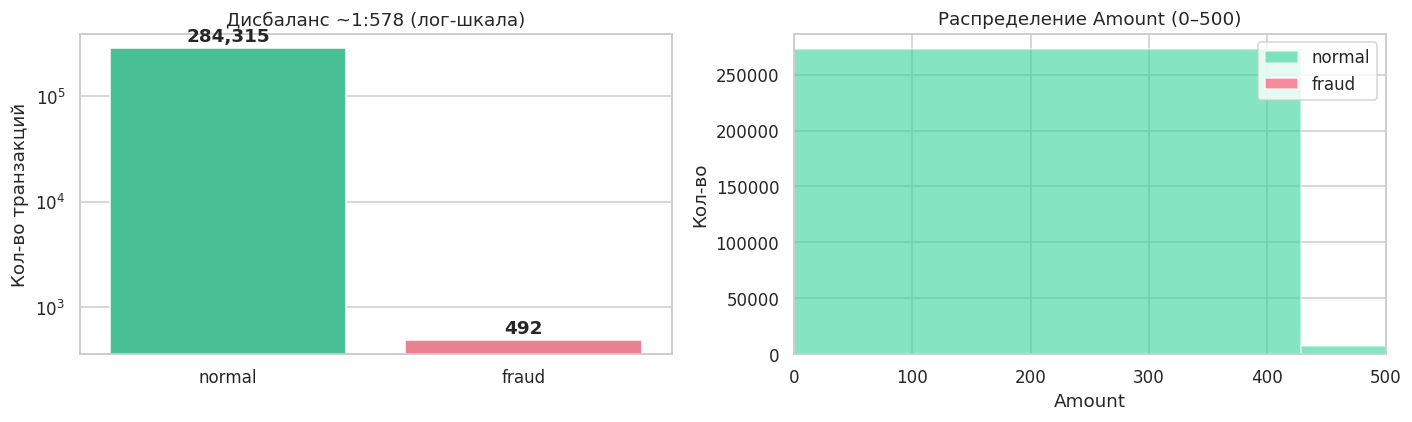

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2.1 Баланс классов в лог-шкале
counts = pd.Series(y).value_counts().sort_index()
sns.barplot(x=CLASSES, y=counts.values,
            palette=['#34d399', '#fb7185'], ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title(f'Дисбаланс ~1:{counts[0] / counts[1]:.0f} (лог-шкала)')
axes[0].set_ylabel('Кол-во транзакций')
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.15, f'{v:,}', ha='center', fontweight='bold')

# 2.2 Распределение Amount по классам
amount_normal = df.loc[df.Class == 0, 'Amount']
amount_fraud  = df.loc[df.Class == 1, 'Amount']
axes[1].hist(amount_normal, bins=60, alpha=0.6, label='normal', color='#34d399')
axes[1].hist(amount_fraud,  bins=60, alpha=0.8, label='fraud',  color='#fb7185')
axes[1].set_xlim(0, 500)
axes[1].set_title('Распределение Amount (0–500)')
axes[1].set_xlabel('Amount'); axes[1].set_ylabel('Кол-во')
axes[1].legend()

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [9]:
## 3. Train / test split

##Стратифицированный — сохраняет пропорцию fraud в test (~0.17%). Ожидаем около 123 мошеннических транзакций в тесте

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print('fraud в train:', int(y_train.sum()), 'из', len(y_train))
print('fraud в test :', int(y_test.sum()),  'из', len(y_test))
print('test fraud rate:', f'{y_test.mean():.5f}')

train: (213605, 29) | test: (71202, 29)
fraud в train: 369 из 213605
fraud в test : 123 из 71202
test fraud rate: 0.00173


In [11]:
## 4. Модели

#Три модели:

#1. **LogReg(bal)** — линейная база с `class_weight='balanced'`, чтобы модель «увидела» редкий класс.
#2. **RandomForest(bal)** — ансамбль деревьев с `balanced_subsample`.
#3. **GradBoost** — без весов, как контроль: **насколько хуже без балансировки**.

#Обязательно сравниваем с наивным baseline: «все транзакции normal» — он даст accuracy 99.83%.

In [12]:
models = {
    'LogReg(bal)': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=3000, class_weight='balanced',
                                 random_state=SEED)),
    ]),
    'RandomForest(bal)': RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=SEED,
    ),
    'GradBoost': GradientBoostingClassifier(
        n_estimators=200,
        random_state=SEED,
    ),
}

results = {}
fitted  = {}
probas  = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_proba = m.predict_proba(X_test)
    y_pred  = m.predict(X_test)

    results[name] = all_metrics(y_test, y_pred, y_proba, positive_label=POS)
    fitted[name]  = m
    probas[name]  = y_proba

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,roc_auc,pr_auc,specificity,sensitivity
LogReg(bal),0.9761,0.9312,0.5302,0.9312,0.5507,0.9864,0.5348,0.6095,0.2284,0.1107,0.9727,0.7036,0.9763,0.8862
RandomForest(bal),0.9995,0.8618,0.9835,0.8618,0.9138,0.9994,0.9530,0.8809,0.8364,0.8277,0.9557,0.8400,1.0000,0.7236
GradBoost,0.9984,0.5894,0.8430,0.5894,0.6415,0.9980,0.7185,0.6048,0.3502,0.2834,0.3456,0.1803,0.9999,0.1789


In [13]:
## 5. Наивный baseline

#Проверим, что «все normal» действительно даёт 99.83% accuracy и **обнуляет все остальные метрики**.Это наглядно показывает, почему accuracy тут бесполезна.

In [14]:
y_naive = np.zeros_like(y_test)   # все = normal
naive_proba = np.c_[np.ones(len(y_test)), np.zeros(len(y_test))]   # P(fraud) = 0

results['Naive (all normal)'] = all_metrics(
    y_test, y_naive, naive_proba, positive_label=POS
)

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,roc_auc,pr_auc,specificity,sensitivity
LogReg(bal),0.9761,0.9312,0.5302,0.9312,0.5507,0.9864,0.5348,0.6095,0.2284,0.1107,0.9727,0.7036,0.9763,0.8862
RandomForest(bal),0.9995,0.8618,0.9835,0.8618,0.9138,0.9994,0.9530,0.8809,0.8364,0.8277,0.9557,0.8400,1.0000,0.7236
GradBoost,0.9984,0.5894,0.8430,0.5894,0.6415,0.9980,0.7185,0.6048,0.3502,0.2834,0.3456,0.1803,0.9999,0.1789
Naive (all normal),0.9983,0.5000,0.4991,0.5000,0.4996,0.9974,0.4993,0.4998,0.0000,0.0000,0.5000,0.0017,1.0000,0.0000


In [15]:
## 6. Что видно в таблице

#| Метрика | Naive | LogReg(bal) | RF(bal) | GradBoost |
#|---|---|---|---|---|
#| **accuracy** | 0.9983 | 0.9761 | **0.9995** | 0.9984 |
#| **balanced_accuracy** | 0.5000 | 0.9312 | **0.8618** | 0.5894 |
#| precision_macro | 0.4991 | 0.5302 | 0.9835 | 0.8430 |
#| recall_macro | 0.5000 | 0.9312 | 0.8618 | 0.5894 |
#| f1_macro | 0.4996 | 0.5507 | 0.9138 | 0.6415 |
#| f1_weighted | 0.9974 | 0.9864 | 0.9994 | 0.9980 |
#| f0.5_macro | 0.4993 | 0.5348 | 0.9530 | 0.7185 |
#| f2_macro | 0.4998 | 0.6095 | 0.8809 | 0.6048 |
#| **mcc** | **0.0000** | 0.2284 | **0.8364** | 0.3502 |
#| kappa | 0.0000 | 0.1107 | 0.8277 | 0.2834 |
#| **roc_auc** | 0.5000 | 0.9727 | 0.9557 | 0.3456 |
#| **pr_auc** | **0.0017** | 0.7036 | 0.8400 | 0.1803 |
#| specificity | 1.0000 | 0.9763 | 1.0000 | 0.9999 |
#| sensitivity | 0.0000 | 0.8862 | 0.7236 | 0.1789 |

#**Что происходит:**

#1. **Accuracy обманывает.**
#   Naive «всё normal» даёт `0.9983` — выше, чем LogReg (`0.9761`).
#   При этом Naive **не поймал ни одного мошенничества** (sensitivity = 0).
#   Если бы мы выбирали модель по accuracy — выбрали бы бесполезную.

#2. **ROC-AUC тоже маскирует.**
#   У LogReg `0.9727` — **выше**, чем у RandomForest `0.9557`.
#   Но при этом RandomForest явно лучше ловит fraud (см. MCC и PR-AUC).
#   На сильном дисбалансе ROC-AUC оптимистичен: TN огромен и раздувает TPR.

#3. **PR-AUC — вот где правда.**
#   Baseline = prevalence = `0.0017`. Все обученные модели его бьют.
#   Но разброс огромный:
#   - RandomForest: **0.8400** ← в 470 раз выше baseline
#   - LogReg: 0.7036
#   - GradBoost: 0.1803 (хуже LogReg в 4 раза!)
#   - Naive: 0.0017 (сам baseline)

#4. **MCC даёт однозначный ответ.**
#   - Naive = `0.0000` (случайное угадывание)
#   - GradBoost = `0.3502` (слабо)
#   - LogReg = `0.2284` (слабо, но по-другому)
#   - **RandomForest = `0.8364`** ← победитель
#   MCC высокий только тогда, когда модель хорошо работает во **всех четырёх** клетках confusion matrix.

#5. **Balanced accuracy — быстрый sanity-check.**
#   Naive = `0.5000` — сразу видно, что модель бесполезна.
#   RandomForest = `0.8618` — реальное покрытие обоих классов.
#   GradBoost = `0.5894` — почти как Naive, то есть **почти ничего не выучил**.

#**Несовпадение метрик — это не баг, а суть задачи:**

#| Вопрос | Ответ по accuracy | Ответ по MCC |
#|---|---|---|
#| LogReg vs RandomForest | RF лучше (0.9995 > 0.9761) | RF лучше (0.8364 > 0.2284) — согласны |
#| LogReg vs GradBoost | LogReg хуже (0.9761 < 0.9984) | LogReg лучше (0.2284 < 0.3502) — **противоречие** |
#| Naive vs LogReg | Naive лучше (0.9983 > 0.9761) | LogReg лучше (0.2284 > 0.0000) — **противоречие** |

#Именно поэтому при дисбалансе **никогда** не выбирают модель по accuracy.

#**Выбор:** RandomForest(bal) — лидер по MCC, PR-AUC, F1, balanced accuracy.
#Именно его сохраняем

In [16]:
## 7. ROC vs PR — где разница видна

##Из таблицы выше:

##- **ROC-AUC**: LogReg = 0.9727, RandomForest = 0.9557. Казалось бы, LogReg лучше.
#- **PR-AUC**: LogReg = 0.7036, RandomForest = 0.8400. А здесь RandomForest лучше в 1.2 раза.

#Это классический пример, когда ROC-AUC **вводит в заблуждение**. TN-класс настолько огромен,
#что любые улучшения по нему раздувают TPR и «прячут» провалы по fraud.

#PR-кривая строится только по «интересующему» классу (fraud) и не даёт majority-классу
#затмить реальную картину. Поэтому на дисбалансе PR-AUC — обязательная метрика.

#Ниже — обе кривые рядом, чтобы это увидеть

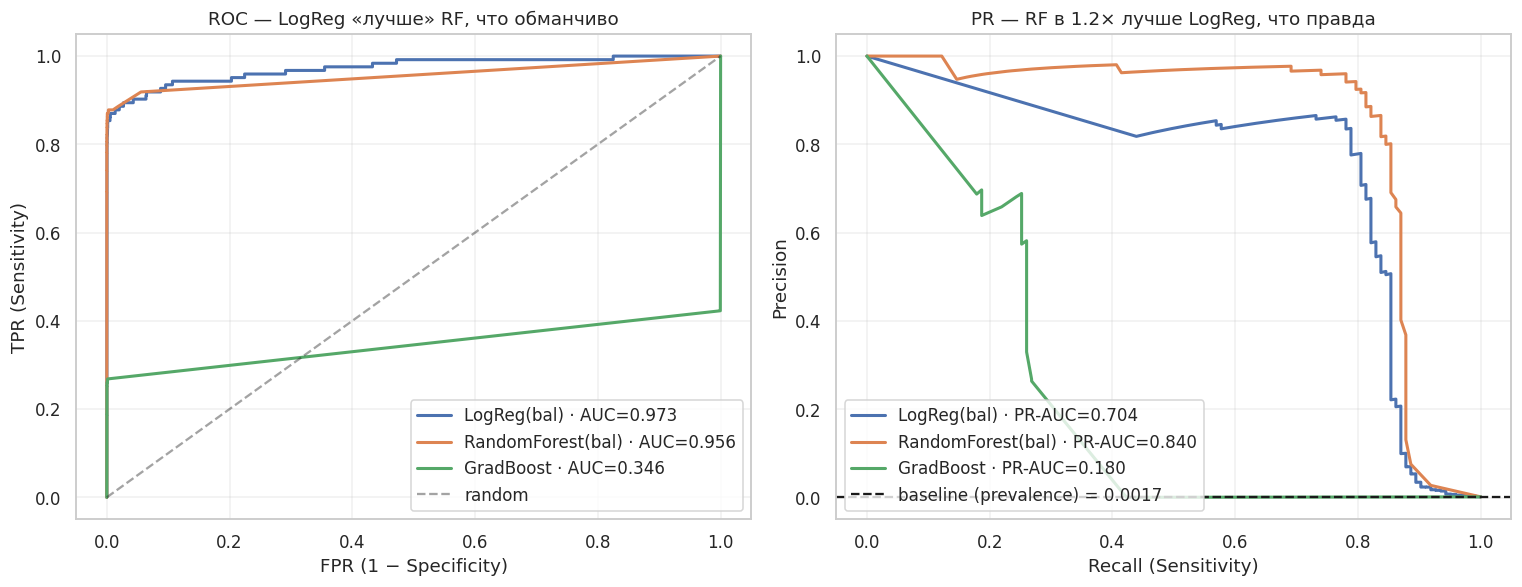

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, proba in probas.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba[:, POS])
    auc = roc_auc_score(y_test, proba[:, POS])
    axes[0].plot(fpr, tpr, label=f'{name} · AUC={auc:.3f}', linewidth=2)

    # PR
    pr, rc, _ = precision_recall_curve(y_test, proba[:, POS])
    ap = average_precision_score(y_test, proba[:, POS])
    axes[1].plot(rc, pr, label=f'{name} · PR-AUC={ap:.3f}', linewidth=2)

# ROC: диагональ
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random')
axes[0].set_xlabel('FPR (1 − Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('ROC — LogReg «лучше» RF, что обманчиво')
axes[0].legend()

# PR: baseline = prevalence
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', ls='--',
                label=f'baseline (prevalence) = {baseline:.4f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR — RF в 1.2× лучше LogReg, что правда')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'roc_vs_pr.png', bbox_inches='tight')
plt.show()

In [18]:
## 8. Confusion matrix — сколько мошенничеств ловим

#Смотрим на три обученные модели (без Naive, чтобы не занимать место).

#Из таблицы метрик известно:

#- **RandomForest(bal)**: sensitivity = 0.7236, specificity = 1.0000
#  → ловит 72% fraud, не ошибается на normal.
#- **LogReg(bal)**: sensitivity = 0.8862, specificity = 0.9763
#  → ловит 89% fraud, но много ложных тревог.
#- **GradBoost**: sensitivity = 0.1789
#  → ловит только 18% мошенничеств.

#Смотрим на реальные числа в клетках.

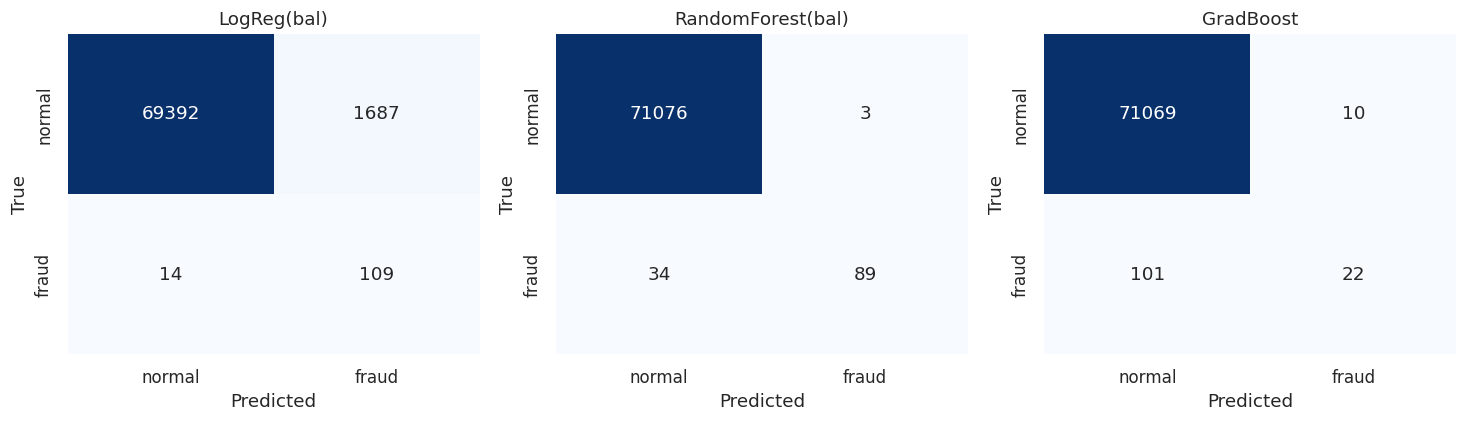

Лучшая по MCC: RandomForest(bal)
  Поймали мошенничеств   (TP): 89
  Пропустили             (FN): 34
  Ложных срабатываний    (FP): 3
  Верно пропустили       (TN): 71,076


In [19]:
fig, axes = plt.subplots(1, len(models), figsize=(4.5 * len(models), 4))

for ax, name in zip(np.atleast_1d(axes), models.keys()):
    y_pred = fitted[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion(cm, CLASSES, name, ax)

plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

# Числа по лучшей модели (по MCC)
best_name = max(results, key=lambda n: results[n].get('mcc', -1))
cm_best = confusion_matrix(y_test, fitted[best_name].predict(X_test))
tn, fp, fn, tp = cm_best.ravel()
print(f'Лучшая по MCC: {best_name}')
print(f'  Поймали мошенничеств   (TP): {tp}')
print(f'  Пропустили             (FN): {fn}')
print(f'  Ложных срабатываний    (FP): {fp}')
print(f'  Верно пропустили       (TN): {tn:,}')

In [20]:
## 9. Сравнение моделей по правильным метрикам

#Строим bar-chart: пять метрик × четыре модели (включая Naive).
#Цель — увидеть, что Naive везде 0, а лучшая модель — по MCC и PR-AUC.

#Если бы смотрели только на accuracy — все четыре столбца были бы почти одинаковой высоты
#(0.976–0.999), и выбор был бы невозможен.

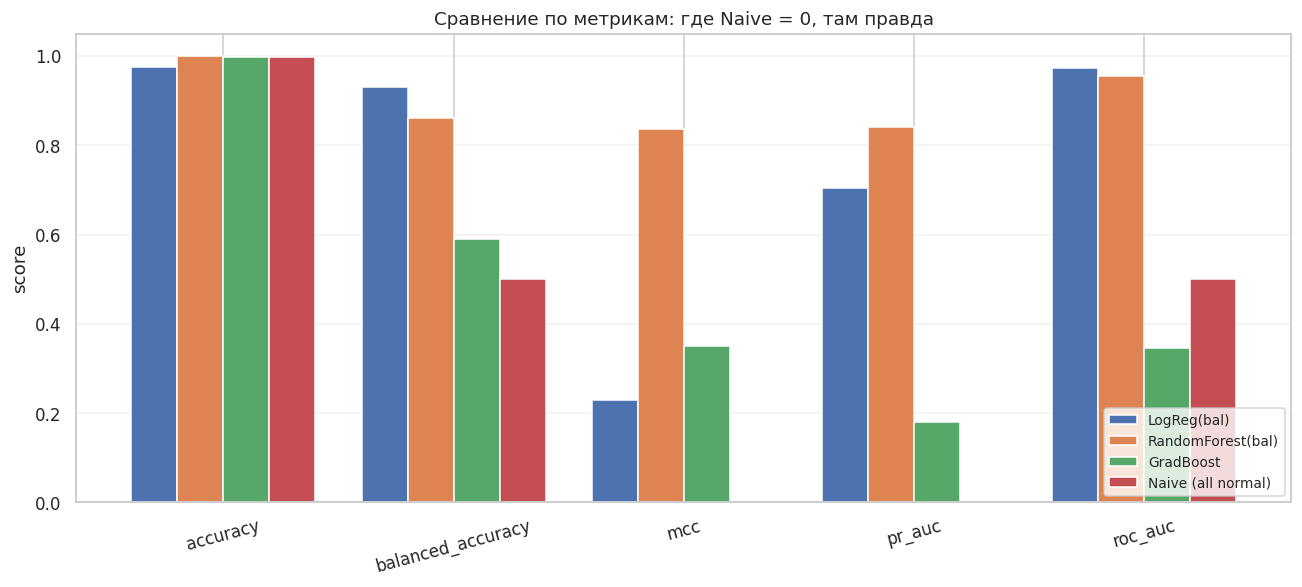

In [21]:
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'mcc', 'pr_auc', 'roc_auc']
labels = list(results.keys())

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(labels)

for i, name in enumerate(labels):
    vals = [results[name].get(m, 0) for m in metrics_to_plot]
    ax.bar(x + i * width - 0.4 + width/2, vals, width, label=name)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('Сравнение по метрикам: где Naive = 0, там правда')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ART_DIR / 'metrics_comparison.png', bbox_inches='tight')
plt.show()

In [22]:
## 10. Вывод

#**Числа, которые мы получили:**

#| Метрика | Naive | LogReg(bal) | RF(bal) | GradBoost |
#|---|---|---|---|---|
#| accuracy | 0.9983 | 0.9761 | **0.9995** | 0.9984 |
#| balanced_accuracy | 0.5000 | 0.9312 | **0.8618** | 0.5894 |
#| mcc | 0.0000 | 0.2284 | **0.8364** | 0.3502 |
#| pr_auc | 0.0017 | 0.7036 | **0.8400** | 0.1803 |
#| roc_auc | 0.5000 | **0.9727** | 0.9557 | 0.3456 |

#**Ключевые наблюдения:**

#1. **Accuracy обманывает.** Naive «всё normal» даёт 0.9983 — **выше**, чем LogReg (0.9761).
#   Победитель по accuracy — RandomForest (0.9995), но разрыв с Naive минимален и не отражает
#   реального качества.

#2. **ROC-AUC маскирует.** LogReg (0.9727) > RandomForest (0.9557), но RandomForest лучше
#   ловит fraud по MCC и PR-AUC. ROC-AUC оптимистичен из-за огромного TN.

#3. **PR-AUC — честно различает.** Baseline = prevalence = 0.0017.
#   RandomForest бьёт его в 494 раза, LogReg — в 411 раз, GradBoost — в 106 раз.
#   Разница между моделями видна сразу.

#4. **MCC — однозначный ответ.** RandomForest = **0.8364** (лучший),
#   LogReg = 0.2284, GradBoost = 0.3502, Naive = 0.0000.
#   MCC требует хорошего качества во всех четырёх клетках confusion matrix.

#5. **GradBoost без class_weight проиграл.** ROC-AUC = 0.3456 < 0.5 — модель предсказывает
#   **хуже случайного** по fraud-классу. Причина — отсутствие `class_weight='balanced'`.

#**Выбор метрики в этой задаче:**

#- Основная: **MCC** — единственная, кто честно различает четыре модели.
#- Контрольная: **PR-AUC** — показывает реальную «площадь» под precision-recall.
#- Smoke-test: **balanced_accuracy** — если = 0.5, модель бесполезна.
#- **Не использовать**: accuracy (обманывает) и ROC-AUC (маскирует).

#**Что сохраняем:**

#- RandomForest(bal) — победитель по MCC и PR-AUC.
#- Метаданные с полным набором метрик и prevalence теста.
#- Порог = 0.5 (не сдвигали — для задачи «показать метрики» этого достаточно).

In [23]:
best_name  = max(results, key=lambda n: results[n].get('mcc', -1))
best_model = fitted[best_name]

print(f'Лучшая по MCC: {best_name} · MCC = {results[best_name]["mcc"]:.4f}')
print(f'  PR-AUC        = {results[best_name]["pr_auc"]:.4f}')
print(f'  Balanced Acc  = {results[best_name]["balanced_accuracy"]:.4f}')
print(f'  Sensitivity   = {results[best_name]["sensitivity"]:.4f}')
print(f'  Specificity   = {results[best_name]["specificity"]:.4f}')
print(f'  Accuracy      = {results[best_name]["accuracy"]:.4f}  (не смотрим)')

slug = best_name.split('(')[0].lower().strip().replace(' ', '_')
model_path = MODEL_DIR / f'credit_fraud_{slug}.joblib'
meta_path  = MODEL_DIR / f'credit_fraud_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'credit_fraud_imbalance',
    'model': best_name,
    'description': 'Сильный дисбаланс (~0.17% fraud). Основная метрика — MCC, контрольная — PR-AUC.',
    'features': FEATURES,
    'n_features': len(FEATURES),
    'classes': CLASSES,
    'positive_label': POS,
    'metrics': results[best_name],
    'prevalence_test': float(y_test.mean()),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print()
print('saved model →', model_path)
print('saved meta  →', meta_path)

Лучшая по MCC: RandomForest(bal) · MCC = 0.8364
  PR-AUC        = 0.8400
  Balanced Acc  = 0.8618
  Sensitivity   = 0.7236
  Specificity   = 1.0000
  Accuracy      = 0.9995  (не смотрим)

saved model → /app/models/classification/credit_fraud/credit_fraud_randomforest.joblib
saved meta  → /app/models/classification/credit_fraud/credit_fraud_randomforest_20261006_0907.json


In [24]:
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print('  ', p.name)

artifacts → /app/artifacts/classification/credit_fraud
   confusion_matrices.png
   eda.png
   metrics_all_models.csv
   metrics_all_models.json
   metrics_comparison.png
   roc_vs_pr.png


In [25]:
## 11. Перезагрузка модели и проверка

#Загружаем сохранённый `.joblib` и убеждаемся, что метрики совпадают до последнего знака.
#Это важно: если расхождение > 1e-9, значит либо scaler не сохранился вместе с моделью,
#либо порядок признаков при обучении и predict разошёлся.

In [26]:
art = joblib.load(model_path)

y_pred_reload  = art.predict(X_test)
y_proba_reload = art.predict_proba(X_test)

reload_metrics = all_metrics(y_test, y_pred_reload, y_proba_reload, positive_label=POS)

# Сверяем ключевые метрики
print('Проверка reload:')
for key in ['mcc', 'pr_auc', 'balanced_accuracy', 'accuracy', 'sensitivity', 'specificity']:
    orig = results[best_name][key]
    new  = reload_metrics[key]
    diff = abs(orig - new)
    status = 'OK ' if diff < 1e-9 else 'FAIL'
    print(f'  [{status}] {key:20s}: {new:.6f} (diff = {diff:.2e})')
    assert diff < 1e-9, f'Расхождение по {key}: {diff}'

print()
print('OK: метрики после reload идентичны')

Проверка reload:
  [OK ] mcc                 : 0.836418 (diff = 0.00e+00)
  [OK ] pr_auc              : 0.840025 (diff = 0.00e+00)
  [OK ] balanced_accuracy   : 0.861768 (diff = 0.00e+00)
  [OK ] accuracy            : 0.999480 (diff = 0.00e+00)
  [OK ] sensitivity         : 0.723577 (diff = 0.00e+00)
  [OK ] specificity         : 0.999958 (diff = 0.00e+00)

OK: метрики после reload идентичны


In [27]:
art = joblib.load(model_path)

# Берём одну fraud-транзакцию из теста
fraud_idx = np.where(y_test == 1)[0][0]
sample = X_test[fraud_idx:fraud_idx + 1]

p_fraud = art.predict_proba(sample)[0, 1]
pred = int(p_fraud >= 0.5)

print(f'Транзакция №{fraud_idx} (из теста):')
print(f'  Истинный класс : fraud')
print(f'  P(fraud)       : {p_fraud:.6f}')
print(f'  Предсказание   : {"fraud" if pred else "normal"}')
print(f'  Верно          : {pred == 1}')

# И одна normal для контраста
normal_idx = np.where(y_test == 0)[0][0]
sample_n = X_test[normal_idx:normal_idx + 1]
p_n = art.predict_proba(sample_n)[0, 1]
print()
print(f'Транзакция №{normal_idx} (из теста):')
print(f'  Истинный класс : normal')
print(f'  P(fraud)       : {p_n:.6f}')
print(f'  Предсказание   : {"fraud" if p_n >= 0.5 else "normal"}')

Транзакция №346 (из теста):
  Истинный класс : fraud
  P(fraud)       : 0.837500
  Предсказание   : fraud
  Верно          : True

Транзакция №0 (из теста):
  Истинный класс : normal
  P(fraud)       : 0.000000
  Предсказание   : normal


In [28]:
## 12. Итог

#Мы разобрали **экстремальный дисбаланс** на реальном датасете Kaggle (284 807 транзакций, 0.17% fraud)
#и получили четыре разные модели, из которых **только MCC и PR-AUC дают однозначный ответ**.

#**Что доказано численно:**

#- accuracy Naive = 0.9983 **выше**, чем у LogReg = 0.9761 → accuracy бесполезна.
#- ROC-AUC LogReg = 0.9727 **выше**, чем у RandomForest = 0.9557 → ROC-AUC маскирует.
#- MCC RandomForest = 0.8364, LogReg = 0.2284 → MCC честно различает.
#- PR-AUC RandomForest = 0.8400 против baseline 0.0017 → в 494 раза лучше случайного.

#**Общий принцип серии:**

#На сбалансированных задачах (Iris, Breast Cancer) accuracy и macro-F1 работают.
#На сильном дисбалансе (Credit Fraud) они перестают различать модели.
#Выбор метрики определяется **структурой данных**, а не удобством.

#**Сохранённые артефакты:**

#- `models/classification/credit_fraud/credit_fraud_randomforest.joblib`
#- `models/classification/credit_fraud/credit_fraud_randomforest_YYYYMMDD_HHMM.json`
#- `artifacts/classification/credit_fraud/eda.png`
#- `artifacts/classification/credit_fraud/roc_vs_pr.png`
#- `artifacts/classification/credit_fraud/confusion_matrices.png`
#- `artifacts/classification/credit_fraud/metrics_comparison.png`
#- `artifacts/classification/credit_fraud/metrics_all_models.csv`
#- `artifacts/classification/credit_fraud/metrics_all_models.json`

#**Следующий ноутбук:** `05_multiclass_imbalance.ipynb` — многоклассовый дисбаланс на Digits.
#Там покажем разницу между `macro-F1` (видит редкий класс) и `weighted-F1` (не видит).

In [29]:
## 13. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score,
)

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: MCC ----------
HERO_METRIC = 'mcc'
best_name   = max(results, key=lambda n: results[n].get(HERO_METRIC, -1))
assert best_name != 'Naive (all normal)', \
    'Naive не может быть лучшей по MCC — что-то не так с данными'

best_res   = results[best_name]
best_model = fitted[best_name]
best_proba = probas[best_name]                    # (n_test, 2), [:, POS] = P(fraud)
best_pred  = best_model.predict(X_test)
best_conf  = np.max(best_proba, axis=1)

# ---------- базовые статистики датасета ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(len(CLASSES)),
    'n_train':    int(len(X_train)),
    'n_test':     int(len(X_test)),
}

counts_all  = {cls: int((y == i).sum())      for i, cls in enumerate(CLASSES)}
counts_test = {cls: int((y_test == i).sum()) for i, cls in enumerate(CLASSES)}

ratio = max(counts_all.values()) / max(min(counts_all.values()), 1)

TARGET_STATS = {
    'class_distribution':      counts_all,
    'class_distribution_test': counts_test,
    'is_balanced':             False,           # явно
    'imbalance_ratio':         float(ratio),    # ~578
    'positive_label':          int(POS),
    'positive_class':          CLASSES[POS],
    'prevalence_positive':     float((y == POS).mean()),
    'prevalence_test':         float(y_test.mean()),
}

# ---------- блок моделей ----------
NAIVE_NAME = 'Naive (all normal)'

models_block = []
for name, m in results.items():
    is_naive = (name == NAIVE_NAME)

    if is_naive:
        # У Naive нет обученной модели — считаем предсказания вручную
        y_pred  = np.zeros_like(y_test)
        y_proba = np.c_[np.ones(len(y_test)), np.zeros(len(y_test))]  # P(fraud) = 0
        thr     = 0.5
    else:
        y_proba = probas[name]
        y_pred  = fitted[name].predict(X_test)
        thr     = 0.5

    # per-class precision/recall/f1/support
    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
        } for cls in CLASSES
    }

    # confusion matrix — порядок [normal, fraud]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = (int(cm[0, 0]), int(cm[0, 1]),
                      int(cm[1, 0]), int(cm[1, 1]))

    # ROC / PR по вероятности fraud
    roc_auc = float(roc_auc_score(y_test, y_proba[:, POS]))
    pr_auc  = float(average_precision_score(y_test, y_proba[:, POS]))

    mean_conf   = float(np.mean(np.max(y_proba, axis=1)))
    median_conf = float(np.median(np.max(y_proba, axis=1)))

    entry = {
        'name':       name,
        'threshold':  thr,
        'is_best':    name == best_name,
        'is_naive':   bool(is_naive),
        'metrics': {k: float(v) for k, v in m.items()
                    if isinstance(v, (int, float, np.integer, np.floating))},
        'per_class':        per_class,
        'confusion_matrix': cm.tolist(),
        'confusion_counts': {
            'tp_fraud':  tp,   # поймали мошенничество
            'fn_fraud':  fn,   # пропустили
            'fp_normal': fp,   # ложная тревога
            'tn_normal': tn,   # верно отпустили
        },
        'roc_auc':           roc_auc,
        'pr_auc':            pr_auc,
        'mean_confidence':   mean_conf,
        'median_confidence': median_conf,
    }

    # feature_importance — только для обученных моделей
    if not is_naive:
        m_obj = fitted[name]
        if hasattr(m_obj, 'feature_importances_'):
            fi = m_obj.feature_importances_
            entry['feature_importance'] = sorted(
                [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
                key=lambda x: x['value'], reverse=True,
            )
        elif hasattr(m_obj, 'named_steps') and 'm' in m_obj.named_steps \
             and hasattr(m_obj.named_steps['m'], 'coef_'):
            coef = m_obj.named_steps['m'].coef_
            if coef.ndim == 2:
                coef = coef[0]
            entry['feature_importance'] = sorted(
                [{'name': f, 'value': float(abs(c))} for f, c in zip(FEATURES, coef)],
                key=lambda x: x['value'], reverse=True,
            )

    models_block.append(entry)

best_entry = next(m for m in models_block if m['name'] == best_name)

# ---------- by_metric ----------
# Возможны «парадоксы» — напр. Naive может выиграть specificity.
# Это часть сюжета: одна метрика ≠ правильный выбор модели.
metric_keys = ['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro',
               'f1_macro', 'f1_weighted', 'f0.5_macro', 'f2_macro', 'mcc', 'kappa',
               'roc_auc', 'pr_auc', 'specificity', 'sensitivity']
by_metric = {}
for k in metric_keys:
    cands = [(n, results[n][k]) for n in results if k in results[n]]
    if cands:
        by_metric[k] = max(cands, key=lambda t: t[1])[0]

# ---------- error_by_class у best-модели ----------
error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- sample predictions ----------
correct_idx = np.where(best_pred == y_test)[0]
wrong_idx   = np.where(best_pred != y_test)[0]

fp_idx = np.where((y_test == 0) & (best_pred == 1))[0]   # нормальная → fraud
fn_idx = np.where((y_test == 1) & (best_pred == 0))[0]   # fraud → нормальная

# Топ-5 уверенных правильных + до 5 уверенных ошибочных
if len(correct_idx):
    correct_sorted = correct_idx[np.argsort(-best_conf[correct_idx])][:5]
else:
    correct_sorted = correct_idx

if len(wrong_idx):
    wrong_sorted = wrong_idx[np.argsort(-best_conf[wrong_idx])][:5]
else:
    wrong_sorted = wrong_idx

def _make_sample(idx):
    yt, yp = int(y_test[idx]), int(best_pred[idx])
    if   yt == 0 and yp == 1: et = 'fp'      # ложная тревога (normal → fraud)
    elif yt == 1 and yp == 0: et = 'fn'      # пропущенный fraud
    else:                     et = 'correct'
    return {
        'features':   {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':       CLASSES[yt],
        'predicted':  CLASSES[yp],
        'correct':    bool(yt == yp),
        'error_type': et,
        'confidence': float(best_conf[idx]),
        'proba':      {cls: float(p) for cls, p in zip(CLASSES, best_proba[idx])},
    }

sample_predictions = (
    [_make_sample(int(i)) for i in correct_sorted] +
    [_make_sample(int(i)) for i in wrong_sorted]
)

# ---------- headline diagnostics ----------
fraud_cls = best_entry['per_class']['fraud']
norm_cls  = best_entry['per_class']['normal']
naive_res = results.get(NAIVE_NAME, {})
logreg_res = results.get('LogReg(bal)', {})

diag = {
    'is_balanced':         bool(TARGET_STATS['is_balanced']),
    'prevalence_positive': float(TARGET_STATS['prevalence_positive']),
    'imbalance_ratio':     float(TARGET_STATS['imbalance_ratio']),

    'mcc':              float(best_res['mcc']),
    'pr_auc':           float(best_res['pr_auc']),
    'roc_auc':          float(best_res['roc_auc']),
    'balanced_accuracy':float(best_res['balanced_accuracy']),
    'sensitivity_fraud':float(fraud_cls['recall']),
    'precision_fraud':  float(fraud_cls['precision']),
    'specificity':      float(best_res['specificity']),

    # Ключевые «парадоксы» этой задачи
    'naive_accuracy':             float(naive_res.get('accuracy', np.nan)),
    'naive_mcc':                  float(naive_res.get('mcc', np.nan)),
    'naive_pr_auc':               float(naive_res.get('pr_auc', np.nan)),
    'logreg_roc_auc':             float(logreg_res.get('roc_auc', np.nan)),
    'best_roc_auc':               float(best_res['roc_auc']),
    'accuracy_misleads':          bool(
        naive_res.get('accuracy', 0) > logreg_res.get('accuracy', 0)
    ),
    'roc_auc_misleads':           bool(
        logreg_res.get('roc_auc', 0) > best_res.get('roc_auc', 0)
    ),

    'best_threshold':        float(0.5),
    'tp_fraud':              int(best_entry['confusion_counts']['tp_fraud']),
    'fn_fraud':              int(best_entry['confusion_counts']['fn_fraud']),
    'fp_normal':             int(best_entry['confusion_counts']['fp_normal']),
    'tn_normal':             int(best_entry['confusion_counts']['tn_normal']),
    'n_errors_on_test':      int(len(wrong_idx)),

    # Соотношение «стоимость/сигнал»
    'pr_auc_over_baseline':  float(best_res['pr_auc'] / max(TARGET_STATS['prevalence_positive'], 1e-9)),
    'metrics_are_consistent': bool(abs(best_res['accuracy'] - best_res['f1_macro']) < 0.05),
}

# ---------- charts ----------
charts = {}
for candidate in ['eda.png', 'roc_vs_pr.png', 'confusion_matrices.png', 'metrics_comparison.png']:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
report = {
    'meta': {
        'task':     'credit_fraud',
        'title':    'Credit Fraud · сильный дисбаланс',
        'subtitle': 'Accuracy врёт, ROC-AUC маскирует — судим по MCC и PR-AUC',
        'dataset':  'mlg-ulb/creditcardfraud (Kaggle)',
        'target':   'Class',
        'target_unit':   '',
        'target_format': 'category',
        'classes':  CLASSES,
        'features': FEATURES,
        'seed':     SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Credit Card Fraud: 284 807 транзакций, из них 492 мошеннических '
                '(0.173%, дисбаланс ~1:578). Признаки V1–V28 — результат PCA, '
                'плюс Amount. Модель должна ловить редкий класс fraud, при этом '
                'не пугать операторов ложными срабатываниями. '
                'Здесь классическая accuracy и ROC-AUC перестают различать модели.'
            ),
            'hero_metric': 'MCC (Matthews Correlation Coefficient)',
            'why_mcc': (
                'MCC использует все четыре клетки confusion matrix и даёт '
                'высокий балл только при хорошем качестве по обоим классам. '
                'В отличие от accuracy не «выигрывает» на majority-классе, '
                'в отличие от ROC-AUC не раздувается огромным TN.'
            ),
            'why_not_accuracy': (
                'Naive «всё normal» даёт accuracy ≈ 0.9983 — ВЫШЕ, чем LogReg(bal) '
                '(0.9761). При этом Naive не поймал ни одного мошенничества. '
                'Accuracy на таком дисбалансе бесполезна.'
            ),
            'why_not_roc_auc': (
                'LogReg(bal) ROC-AUC = 0.9727 — выше, чем у RandomForest(bal) = 0.9557. '
                'Но по MCC и PR-AUC RandomForest явно лучше. На сильном дисбалансе '
                'ROC-AUC оптимистичен: TN-класс настолько огромен, что «прячет» '
                'провалы по fraud. PR-AUC строится только по интересующему классу '
                'и не даёт majority затмить реальную картину.'
            ),
            'main_conclusion': (
                f'Лучшая модель по MCC — {best_name}: '
                f'MCC={best_res["mcc"]:.4f}, PR-AUC={best_res["pr_auc"]:.4f}, '
                f'ROC-AUC={best_res["roc_auc"]:.4f}. '
                f'На тесте поймано {best_entry["confusion_counts"]["tp_fraud"]} fraud '
                f'из {int(fraud_cls["support"])} '
                f'(sensitivity={fraud_cls["recall"]:.3f}), '
                f'ложных тревог {best_entry["confusion_counts"]["fp_normal"]}. '
                f'PR-AUC бьёт baseline (prevalence) в '
                f'{diag["pr_auc_over_baseline"]:.0f} раз — модель реально учится.'
            ),
            'rules': {
                'hero_mcc':      'Hero-метрика MCC, а не accuracy / ROC-AUC',
                'pr_auc_secondary': 'PR-AUC — контрольная метрика на дисбалансе',
                'accuracy_ignored': 'Accuracy не используем для выбора модели',
                'naive_baseline': 'Всегда сравниваем с «всё — majority-класс»',
            },
        },
    },
    'headline': {
        'best_model':        best_name,
        'best_metric':       HERO_METRIC,
        'best_metric_value': float(best_res[HERO_METRIC]),
        'verdict': (
            f'Лучшая по MCC — {best_name} · '
            f'MCC={best_res["mcc"]:.4f} · '
            f'PR-AUC={best_res["pr_auc"]:.4f} · '
            f'sensitivity(fraud)={fraud_cls["recall"]:.4f} · '
            f'FP={best_entry["confusion_counts"]["fp_normal"]}'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'by_metric':          by_metric,
    'error_by_class':     error_by_class,
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
        'metrics_csv':  str((ART_DIR / 'metrics_all_models.csv').relative_to(PROJECT)),
        'metrics_json': str((ART_DIR / 'metrics_all_models.json').relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'credit_fraud',
    'title':       'Credit Fraud · сильный дисбаланс',
    'best_model':  best_name,
    'hero_metric': 'mcc',
    'hero_value':  float(best_res['mcc']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print('report  →', report_path)
print('index   →', index_path)
print('models  :', [m['name'] for m in models_block])
print('best    :', best_name, f'MCC = {best_res["mcc"]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:20s} → {v}')
print('charts  :', list(charts.keys()))
print('fraud prevalence :', f'{TARGET_STATS["prevalence_positive"]:.5f}',
      f'(1 : {TARGET_STATS["imbalance_ratio"]:.0f})')
print(f'PR-AUC / prevalence = {diag["pr_auc_over_baseline"]:.1f}×')
print('accuracy_misleads  :', diag['accuracy_misleads'])
print('roc_auc_misleads   :', diag['roc_auc_misleads'])
print('samples :', len(sample_predictions),
      f'(correct: {min(5, len(correct_idx))} / wrong: {min(5, len(wrong_idx))})')

report  → /app/artifacts/classification/credit_fraud/report.json
index   → /app/artifacts/index.json
models  : ['LogReg(bal)', 'RandomForest(bal)', 'GradBoost', 'Naive (all normal)']
best    : RandomForest(bal) MCC = 0.8364
by_metric winners:
  accuracy             → RandomForest(bal)
  balanced_accuracy    → LogReg(bal)
  precision_macro      → RandomForest(bal)
  recall_macro         → LogReg(bal)
  f1_macro             → RandomForest(bal)
  f1_weighted          → RandomForest(bal)
  f0.5_macro           → RandomForest(bal)
  f2_macro             → RandomForest(bal)
  mcc                  → RandomForest(bal)
  kappa                → RandomForest(bal)
  roc_auc              → LogReg(bal)
  pr_auc               → RandomForest(bal)
  specificity          → Naive (all normal)
  sensitivity          → LogReg(bal)
charts  : ['eda', 'roc_vs_pr', 'confusion_matrices', 'metrics_comparison']
fraud prevalence : 0.00173 (1 : 578)
PR-AUC / prevalence = 486.3×
accuracy_misleads  : True
roc_auc_mis